In [1]:
import typing
import os
import torch
from torch.nn.functional import cross_entropy
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_from_disk, load_dataset
from tqdm import tqdm

/root/dev/repos/moe-routing/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
from display_token_ppls import display_ppl_in_notebook

In [3]:
main_device = 'auto'
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [4]:
torch.random.manual_seed(19260817)
TOTAL_ENTRIES = 1

In [5]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-30B-A3B", device_map=main_device, torch_dtype=torch.bfloat16, attn_implementation="flash_attention_2",)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-30B-A3B", device_map=main_device)

dataset = load_dataset("lmsys/lmsys-chat-1m", split="train")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/16 [00:00<?, ?it/s]

In [6]:
spec_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-0.6B", device_map=main_device, torch_dtype=torch.bfloat16, attn_implementation="flash_attention_2",)

In [7]:
model.eval()
model.config.use_cache = False
model.config.output_logits = True

In [38]:
def calc_perplexity(logits, token_ids):
  logits = logits.float()
  assert logits.shape[:-1] == token_ids.shape, \
      f"Logits shape {logits.shape} does not match token_ids shape {token_ids.shape}"
  loss = cross_entropy(logits.view(-1, logits.size(-1)), token_ids.view(-1), reduction='none')
  perplexity = torch.exp(loss)
  return perplexity.view(token_ids.shape)


In [9]:
# for entry in tqdm(dataset.take(TOTAL_ENTRIES).to_iterable_dataset(), total=TOTAL_ENTRIES):
for entry in tqdm(dataset.select(range(TOTAL_ENTRIES))):
  chat = tokenizer.apply_chat_template(entry["conversation"], tokenize=False)
  inputs = tokenizer(chat, return_tensors="pt").to(model.device)

  with torch.no_grad():
    outputs = model(**inputs)

  input_ids = inputs.input_ids[0]
  input_length = input_ids.size(0)
  target_ids = input_ids[1:]

  # Calculate perplexity from logits.
  # Remove the last token to avoid sampling the next token
  output_logits = outputs.logits[0, :-1, :]  # [batch_size, seq_len, vocab_size]
  full_perplexity = calc_perplexity(output_logits, target_ids)
  print(f"Full Perplexity: {full_perplexity.mean().item()}")

  base_top_k = model.config.num_experts_per_tok
  token_top_ks = torch.where(full_perplexity > 1.2, base_top_k, base_top_k-1)
  # Append the last token to match the input length
  token_top_ks = torch.cat([token_top_ks, torch.tensor([base_top_k], device=model.device)], dim=0)

  with torch.no_grad():
    outputs = model(
      **inputs,
      token_top_ks=token_top_ks,
    )

  output_logits = outputs.logits[0, :-1, :]
  reduced_perplexity = calc_perplexity(output_logits, target_ids)
  print(f"Reduced Perplexity: {reduced_perplexity.mean().item()}")

  0%|          | 0/1 [00:00<?, ?it/s]

Full Perplexity: 113816633344.0


100%|██████████| 1/1 [00:04<00:00,  4.21s/it]

Reduced Perplexity: 129385889792.0


In [10]:
ceval_data = load_dataset('ceval/ceval-exam', 'accountant', split='test')

In [11]:
from jinja2 import Template
doc_to_text_template = Template("{{question.strip()}}\nA. {{A}}\nB. {{B}}\nC. {{C}}\nD. {{D}}\n<think>")
chat = doc_to_text_template.render(ceval_data[0])
print(chat)

下列关于资本结构理论的说法中，不正确的是____。
A. 代理理论、权衡理论、有企业所得税条件下的MM理论，都认为企业价值与资本结构有关
B. 按照优序融资理论的观点，考虑信息不对称和逆向选择的影响，管理者偏好首选留存收益筹资，然后是发行新股筹资，最后是债务筹资
C. 权衡理论是对有企业所得税条件下的MM理论的扩展
D. 代理理论是对权衡理论的扩展
<think>


In [22]:
from transformers import StopStringCriteria, StoppingCriteriaList

inputs = tokenizer(chat, return_tensors="pt").to(model.device)
stop_util_end_think = StopStringCriteria(
  tokenizer=tokenizer,
  stop_strings=["</think>", "<|end_of_turn|>"],
)
outputs = model.generate(
  **inputs,
  max_new_tokens=4096,
  return_dict_in_generate=True,
  output_logits=True,
  stopping_criteria=StoppingCriteriaList([
    stop_util_end_think
  ]),
)

In [25]:
outputs.sequences[0].shape

torch.Size([3998])

In [ ]:
temp_conversation = tokenizer.decode(outputs.sequences[0])

In [12]:
with open('../../data/dyn_topk/ceval/temp_conversation.txt', 'r') as f:
  temp_conversation = f.read()

In [13]:
print(temp_conversation)

下列关于资本结构理论的说法中，不正确的是____。
A. 代理理论、权衡理论、有企业所得税条件下的MM理论，都认为企业价值与资本结构有关
B. 按照优序融资理论的观点，考虑信息不对称和逆向选择的影响，管理者偏好首选留存收益筹资，然后是发行新股筹资，最后是债务筹资
C. 权衡理论是对有企业所得税条件下的MM理论的扩展
D. 代理理论是对权衡理论的扩展
<think>
嗯，我现在要解决这个关于资本结构理论的选择题，题目是问哪个说法不正确。选项是A到D四个。首先，我需要回忆一下各个资本结构理论的基本内容，然后逐一分析每个选项是否正确。

首先，资本结构理论主要包括几个主要的理论：MM理论（包括有税和无税情况）、权衡理论、代理理论、优序融资理论等等。我需要先明确每个理论的核心观点，然后再看题目中的各个选项是否符合这些理论。

题目中的选项：

A选项说代理理论、权衡理论、有企业所得税条件下的MM理论都认为企业价值与资本结构有关。这个是否正确呢？首先，MM理论在有税的情况下，认为企业价值会随着负债的增加而增加，因为利息税盾的作用，所以企业价值与资本结构有关。权衡理论则是说企业会在债务的税盾利益和财务困境成本之间权衡，所以企业价值也与资本结构有关。代理理论的话，应该是指代理成本的存在，比如债务会导致股东和债权人之间的代理成本，或者股东与管理者之间的代理成本，这些都会影响企业价值，所以代理理论也应该认为资本结构影响企业价值。因此A选项的说法是对的，所以A正确，不是答案。

B选项说按照优序融资理论，考虑信息不对称和逆向选择的影响，管理者偏好首选留存收益筹资，然后是发行新股筹资，最后是债务筹资。这里可能有问题。根据优序融资理论，企业的融资顺序是首先内部融资（比如留存收益），然后是债务融资，最后才是发行新股。因为如果公司发行新股，可能被市场解读为股价被高估，导致逆向选择问题。所以正确的顺序应该是留存收益→债务→新股。而B选项中说“然后是发行新股筹资，最后是债务筹资”，这明显顺序错误，应该是先债务，再新股。所以B选项的说法不正确，可能就是答案。不过我需要再确认一下。

C选项说权衡理论是对有企业所得税条件下的MM理论的扩展。这里需要明确权衡理论和MM理论的关系。MM理论在有税的情况下，认为负债越多企业价值越高，但权衡理论则是在此基础上考虑了财务困境成本，所以权衡理论是对MM理论的扩展，

In [14]:
prefix_len = len(tokenizer.encode(chat))
prefix_len

109

In [39]:
inputs = tokenizer(temp_conversation, return_tensors="pt").to(model.device)

with torch.no_grad():
  spec_outputs = model(**inputs)

input_ids = inputs.input_ids[0]
input_length = input_ids.size(0)
target_ids = input_ids[1:]

# Calculate perplexity from logits.
# Remove the last token to avoid sampling the next token
full_output_logits = spec_outputs.logits[0, :-1, :]  # [batch_size, seq_len, vocab_size]
full_perplexity = calc_perplexity(full_output_logits, target_ids)
print(f"Full Perplexity: {full_perplexity[prefix_len:].mean().item()}")

base_top_k = model.config.num_experts_per_tok
token_top_ks = base_top_k
token_top_ks = torch.where(full_perplexity < 2.0, base_top_k - 1, token_top_ks)
token_top_ks = torch.where(full_perplexity < 1.02, base_top_k - 2, token_top_ks)
token_top_ks = torch.where(full_perplexity < 1.004, base_top_k - 3, token_top_ks)
# token_top_ks = torch.where(full_perplexity < 1.1, base_top_k - 4, token_top_ks)
# token_top_ks = torch.where(full_perplexity > 4.0, base_top_k - 3, token_top_ks)
# Append the last token to match the input length
token_top_ks = torch.cat([token_top_ks, torch.tensor([base_top_k], device=model.device)], dim=0)

with torch.no_grad():
  reduced_outputs = model(
    **inputs,
    token_top_ks=token_top_ks,
  )

reduced_output_logits = reduced_outputs.logits[0, :-1, :]
reduced_perplexity = calc_perplexity(reduced_output_logits, target_ids)
print(f"Reduced Perplexity: {reduced_perplexity[prefix_len:].mean().item()}")

Full Perplexity: 1.5326018333435059
Reduced Perplexity: 3.210883140563965


In [40]:
with torch.no_grad():
  spec_outputs = spec_model(**inputs)

# Calculate perplexity from logits.
# Remove the last token to avoid sampling the next token
spec_output_logits = spec_outputs.logits[0, :-1, :]  # [batch_size, seq_len, vocab_size]
spec_perplexity = calc_perplexity(spec_output_logits, target_ids)
print(f"Spec Perplexity: {spec_perplexity[prefix_len:].mean().item()}")

Spec Perplexity: 7377.09765625


In [41]:
(spec_perplexity < 1.014).sum() / spec_perplexity.numel()

tensor(0.2375, device='cuda:0')

In [42]:
val, cnt = spec_perplexity.unique(return_counts=True)
# print(val)
print(cnt)
print(cnt.numel(), spec_perplexity.numel())

tensor([ 5,  1, 13,  ...,  1,  1,  1], device='cuda:0')
3896 3996


In [24]:
spec_perplexity.sort()

torch.return_types.sort(
values=tensor([1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 6.8096e+04, 2.7394e+07,
        1.4431e+12], device='cuda:0', dtype=torch.bfloat16),
indices=tensor([  20,   38,   39,  ..., 2224,  109,  107], device='cuda:0'))

In [34]:
spec_output_logits[20].float()

tensor([0.5547, 7.2812, 4.6875,  ..., 1.5859, 1.5859, 1.5859], device='cuda:0')

In [35]:
calc_perplexity(spec_output_logits[20].float(), target_ids[20])

tensor(1.0016, device='cuda:0')

In [35]:
(full_perplexity < 1.004).sum() / full_perplexity.numel()

tensor(0.3544, device='cuda:0')

In [148]:
full_formula = [2, 1.02, 1.004, 1.004]
spec_formula = [6, 1.17, 1.07, 1.07]
spec_formula_aggr = [6, 1.17, 1.07, 1.035, 1.005, 1.005]

In [21]:
def get_assisted_topks(
    cfg: typing.Sequence[float],
    ppls: torch.FloatTensor,
    k: int
):
    ks = torch.full_like(ppls, k, dtype=torch.int64)
    for i, nk in zip(cfg, range(k)[::-1]):
        ks[ppls < i] = nk
    return ks

In [22]:
spec_perplexity < 6.0

tensor([False, False,  True,  ...,  True,  True,  True], device='cuda:0')

In [28]:
inputs = tokenizer(temp_conversation, return_tensors="pt").to(model.device)

with torch.no_grad():
  spec_outputs = spec_model(**inputs)

input_ids = inputs.input_ids[0]
input_length = input_ids.size(0)
target_ids = input_ids[1:]

# Calculate perplexity from logits.
# Remove the last token to avoid sampling the next token
spec_output_logits = spec_outputs.logits[0, :-1, :]  # [batch_size, seq_len, vocab_size]
spec_perplexity = calc_perplexity(spec_output_logits, target_ids)
print(f"Spec Perplexity: {spec_perplexity[prefix_len:].mean().item()}")

base_top_k = model.config.num_experts_per_tok
num_layers = model.config.num_hidden_layers

def calc(formula):
  all_layer_ks = []
  for lid in range(num_layers):
    layer_ks = torch.full_like(input_ids, base_top_k).unsqueeze(0)
    if lid in range(20, 25):
        # do not apply any dyn ks
        cfg = []
    else:
        cfg = formula
    layer_ks[:, :-1] = get_assisted_topks(cfg, spec_perplexity, base_top_k)
    all_layer_ks.append(layer_ks)

  token_top_ks = torch.stack(all_layer_ks)
  assert token_top_ks.ndim == 3, "Must be [layer, batch, seq] shape"

  benefit = (token_top_ks.sum() / (token_top_ks.numel() * 8)).item()

  with torch.no_grad():
    reduced_outputs = model(
      **inputs,
      token_top_ks=token_top_ks,
    )

  reduced_output_logits = reduced_outputs.logits[0, :-1, :]
  reduced_perplexity = calc_perplexity(reduced_output_logits, target_ids)
  avg_ppl = reduced_perplexity[prefix_len:].mean().item()

  return avg_ppl, benefit

for formula in [
   (6, 1.17, 1.07, 1.07),
   (6, 1.16, 1.09, 1.07),
   (6, 1.15, 1.11, 1.07),
   (6, 1.14, 1.13, 1.07),

   (6, 1.18, 1.09, 1.07),
   (6, 1.19, 1.09, 1.07),
   (6, 1.20, 1.09, 1.07),
   (6, 1.21, 1.09, 1.07),

   (6, 1.18, 1.07, 1.07),
   (6, 1.19, 1.07, 1.07),
   (6, 1.20, 1.07, 1.07),
   (6, 1.21, 1.07, 1.07),
]:
   avg_ppl, benefit = calc(formula)
   print(f"Formula: {formula}, Avg PPL: {avg_ppl}, Benefit: {benefit}")

print(f"Full Perplexity: {full_perplexity[prefix_len:].mean().item()}")

Spec Perplexity: 7136.0
Formula: (6, 1.17, 1.07, 1.07), Avg PPL: 97.0, Benefit: 0.7773023843765259
Formula: (6, 1.16, 1.09, 1.07), Avg PPL: 592.0, Benefit: 0.7757895588874817
Formula: (6, 1.15, 1.11, 1.07), Avg PPL: 1664.0, Benefit: 0.7743047475814819
Formula: (6, 1.14, 1.13, 1.07), Avg PPL: 4352.0, Benefit: 0.7724837064743042
Formula: (6, 1.18, 1.09, 1.07), Avg PPL: 836.0, Benefit: 0.7740805745124817
Formula: (6, 1.19, 1.09, 1.07), Avg PPL: 169.0, Benefit: 0.773520290851593
Formula: (6, 1.2, 1.09, 1.07), Avg PPL: 476.0, Benefit: 0.7725397348403931
Formula: (6, 1.21, 1.09, 1.07), Avg PPL: 83.5, Benefit: 0.7721194624900818
Formula: (6, 1.18, 1.07, 1.07), Avg PPL: 101.0, Benefit: 0.7767701148986816
Formula: (6, 1.19, 1.07, 1.07), Avg PPL: 3440.0, Benefit: 0.7762097716331482
Formula: (6, 1.2, 1.07, 1.07), Avg PPL: 115.0, Benefit: 0.7752292156219482
Formula: (6, 1.21, 1.07, 1.07), Avg PPL: 17024.0, Benefit: 0.7748090028762817
Full Perplexity: 1.53125


In [25]:
(spec_perplexity < 6.0).sum() / spec_perplexity.numel()

tensor(0.8446, device='cuda:0')

In [27]:
spec_perplexity.unique(return_counts=True)

(tensor([1.0000e+00, 1.0078e+00, 1.0156e+00, 1.0234e+00, 1.0312e+00, 1.0391e+00,
         1.0469e+00, 1.0547e+00, 1.0625e+00, 1.0703e+00, 1.0781e+00, 1.0859e+00,
         1.0938e+00, 1.1016e+00, 1.1094e+00, 1.1172e+00, 1.1250e+00, 1.1328e+00,
         1.1406e+00, 1.1484e+00, 1.1562e+00, 1.1641e+00, 1.1719e+00, 1.1797e+00,
         1.1875e+00, 1.1953e+00, 1.2031e+00, 1.2109e+00, 1.2188e+00, 1.2266e+00,
         1.2344e+00, 1.2422e+00, 1.2500e+00, 1.2578e+00, 1.2656e+00, 1.2734e+00,
         1.2812e+00, 1.2891e+00, 1.2969e+00, 1.3047e+00, 1.3125e+00, 1.3203e+00,
         1.3281e+00, 1.3359e+00, 1.3438e+00, 1.3516e+00, 1.3594e+00, 1.3672e+00,
         1.3750e+00, 1.3828e+00, 1.3906e+00, 1.3984e+00, 1.4062e+00, 1.4141e+00,
         1.4219e+00, 1.4297e+00, 1.4375e+00, 1.4453e+00, 1.4531e+00, 1.4609e+00,
         1.4688e+00, 1.4766e+00, 1.4844e+00, 1.4922e+00, 1.5000e+00, 1.5078e+00,
         1.5156e+00, 1.5234e+00, 1.5312e+00, 1.5391e+00, 1.5469e+00, 1.5547e+00,
         1.5625e+00, 1.5703e

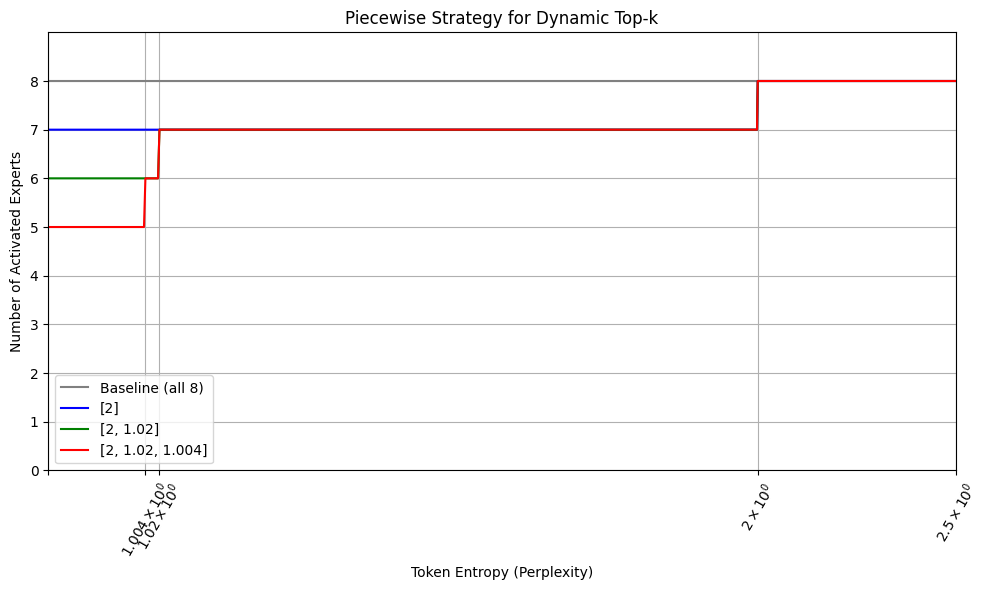

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Baseline value
k = 8

# Different configurations
cfg_list = [
    [],
    [2],
    [2, 1.02],
    [2, 1.02, 1.004],
    [2, 1.02, 1.004, 1.004],
]

# Set up x-axis: perplexity values (descending sort to match typical entropy scale)
x = torch.linspace(0.9, 2.5, steps=1000)  # range covering all thresholds
x_np = x.numpy()

# Create the plot
plt.figure(figsize=(10, 6))
colors = ['gray', 'blue', 'green', 'red']
labels = [
    "Baseline (all 8)",
    "[2]",
    "[2, 1.02]",
    "[2, 1.02, 1.004]",
    "[2, 1.02, 1.004, 1.004]",
]

for cfg, color, label in zip(cfg_list, colors, labels):
    ks = torch.full_like(x, k, dtype=torch.int64)
    for th, nk in zip(cfg, range(k - 1, -1, -1)):
        ks[x < th] = nk
    plt.plot(x_np, ks.numpy(), label=label, color=color)

# Annotate plot
plt.xlabel("Token Entropy (Perplexity)")
plt.ylabel("Number of Activated Experts")
plt.title("Piecewise Strategy for Dynamic Top-k")
plt.legend()
plt.grid(True)
plt.xlim(0.9, 2.5)
plt.ylim(0, 9)
plt.xscale('log')
plt.xticks(np.round(np.unique(np.concatenate([[0.9, 2.5]] + cfg_list)), 4))  # ensure all thresholds are on axis
plt.xticks(rotation=60)
plt.yticks(range(0, 9))
plt.tight_layout()
plt.show()


In [19]:
display_ppl_in_notebook(tokenizer.batch_decode(target_ids)[prefix_len:], full_perplexity.log().tolist()[prefix_len:])

In [59]:
display_ppl_in_notebook(tokenizer.batch_decode(target_ids)[prefix_len:], reduced_perplexity.log().tolist()[prefix_len:])

In [89]:
print(full_perplexity[prefix_len:].mean())
reduced_perplexity[prefix_len:].mean()

tensor(1.5312, device='cuda:0', dtype=torch.bfloat16)


tensor(1.6719, device='cuda:0', dtype=torch.bfloat16)

In [56]:
# show index and value of top-10
reduced_perplexity[prefix_len:].argsort(descending=True)[:10]

tensor([ 346,  368,  713, 3853, 2825, 2755,  839, 1283, 3587, 1091],
       device='cuda:0')

In [24]:
pos_to_inspect = 346
# pos_to_inspect = 368
# pos_to_inspect = 713

In [25]:
token_choices = full_output_logits[prefix_len:][pos_to_inspect]
top_tokens = token_choices.argsort(descending=True)[:10]
print(tokenizer.batch_decode(top_tokens))
print(token_choices[top_tokens])

['逆', '股价', '新股', '股东', '价值', '融资', '信息', '公司', '股权', '股票']
tensor([29.5000, 29.0000, 26.1250, 24.6250, 23.8750, 23.1250, 22.8750, 22.7500,
        22.7500, 22.6250], device='cuda:0', dtype=torch.bfloat16)


In [26]:
token_choices = reduced_output_logits[prefix_len:][pos_to_inspect]
top_tokens = token_choices.argsort(descending=True)[:10]
print(tokenizer.batch_decode(top_tokens))
print(token_choices[top_tokens])

['股价', '新股', '逆', '股东', '融资', '价值', '公司', '股权', '股票', '市值']
tensor([30.7500, 27.1250, 25.0000, 24.7500, 24.6250, 24.0000, 23.7500, 23.7500,
        23.1250, 22.8750], device='cuda:0', dtype=torch.bfloat16)


In [27]:
tokenizer.decode(target_ids[prefix_len:][pos_to_inspect])

'逆'

In [28]:
reduced_perplexity[prefix_len+pos_to_inspect]

tensor(324., device='cuda:0', dtype=torch.bfloat16)

In [31]:
(full_perplexity > 2.0).sum() / full_perplexity.shape[0]

tensor(0.1507, device='cuda:0')